N=36497 M=11 load_sec=0.28


Batches: 100%|██████████| 143/143 [00:21<00:00,  6.71it/s]


X shape=(36497, 384) embed_sec=24.95
offline=3650 test=32847 seed=110 rand=3540
rho_pos=0.99 rho_neg=-0.6
avg_pos=44.5 avg_neg=77.3
ep=1 loss=1.4403 ok_ratio=0.818
ep=20 loss=0.3940 ok_ratio=0.818
ep=40 loss=0.2089 ok_ratio=0.818
ep=60 loss=0.1883 ok_ratio=0.818
ep=80 loss=0.1831 ok_ratio=0.818
ep=100 loss=0.1803 ok_ratio=0.818
ep=120 loss=0.1787 ok_ratio=0.818
ep=140 loss=0.1778 ok_ratio=0.818
ep=160 loss=0.1772 ok_ratio=0.818
ep=180 loss=0.1767 ok_ratio=0.818
ep=200 loss=0.1761 ok_ratio=0.818
train_sec=1.6


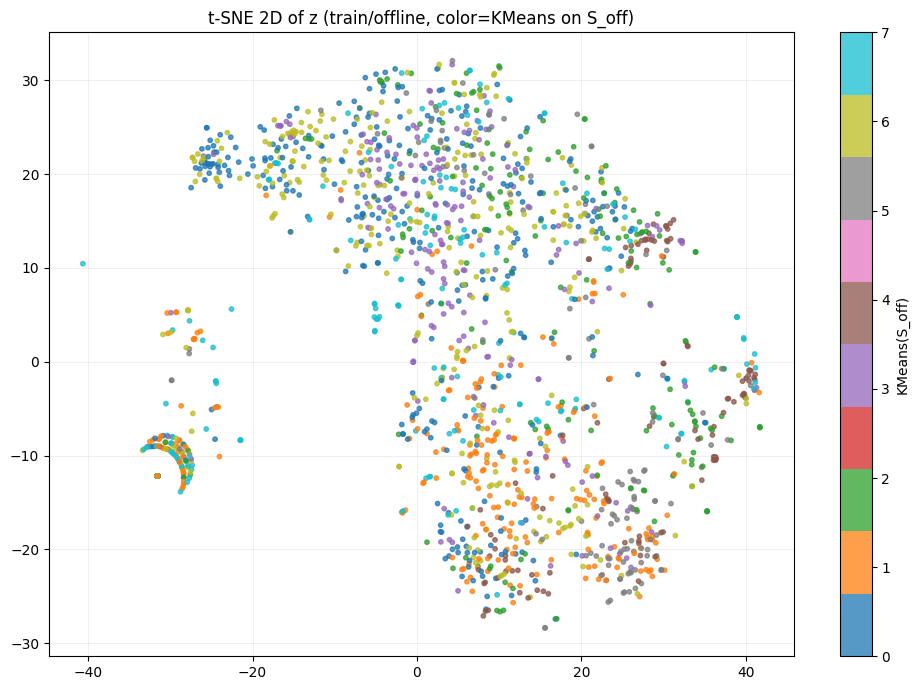

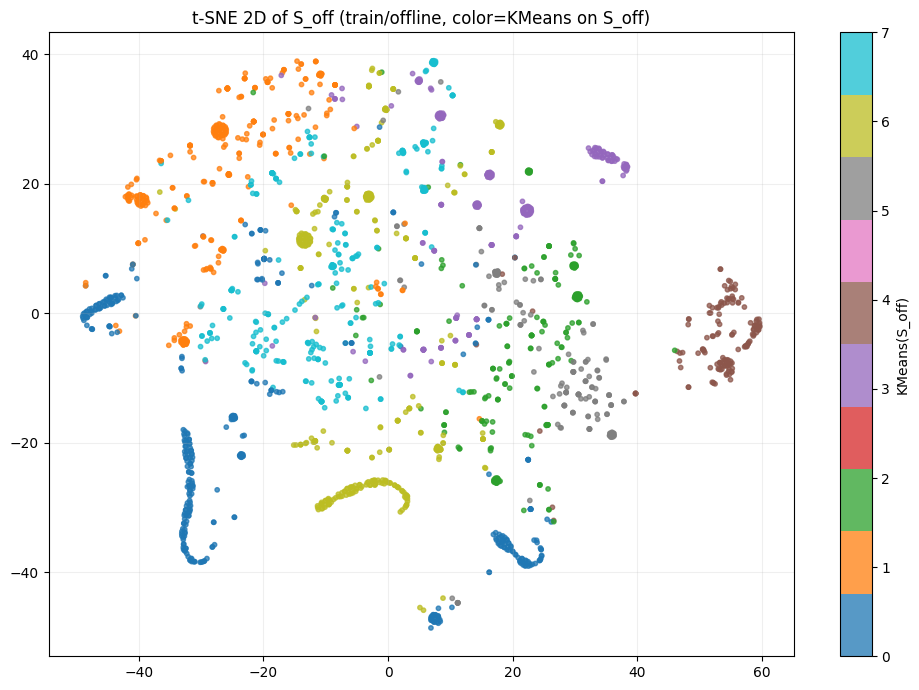

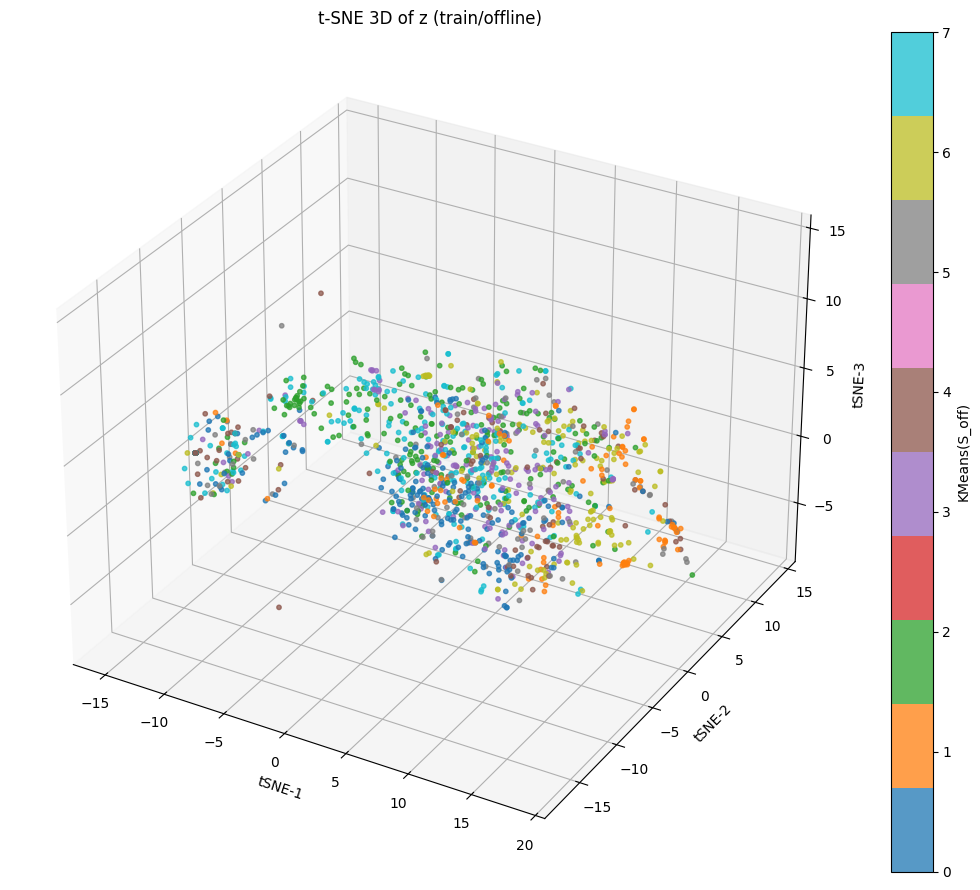

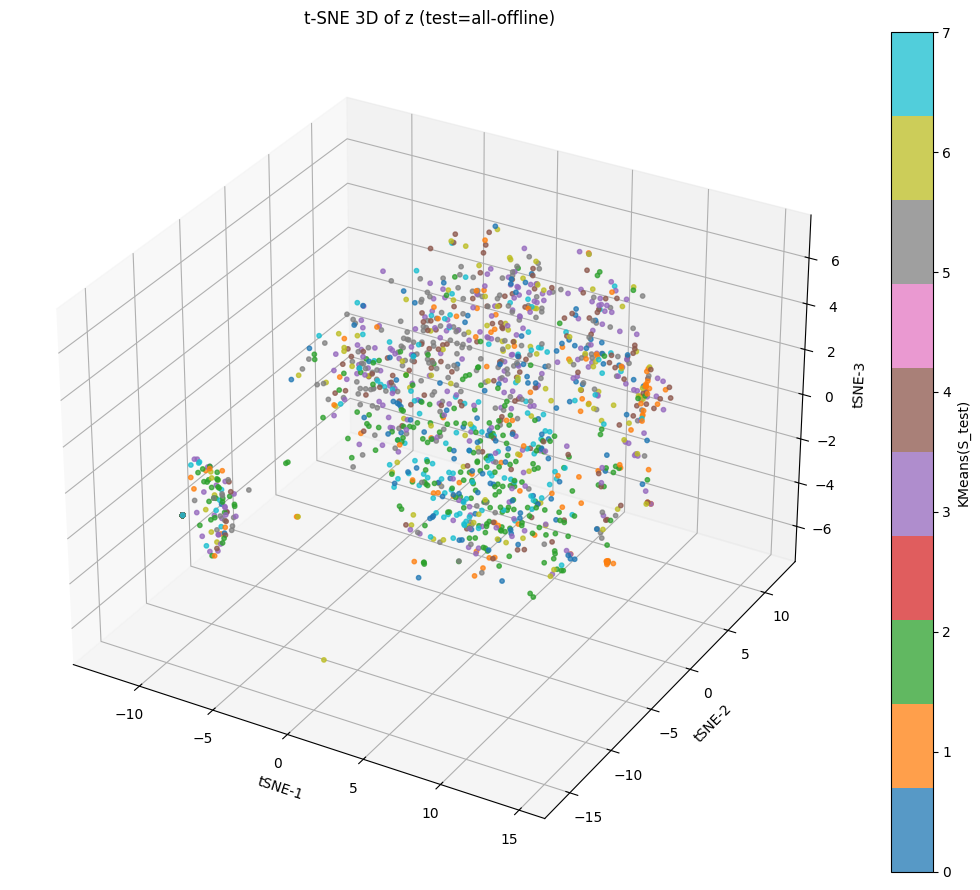

In [ ]:
import math, random, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
torch.set_num_threads(1)



def l2norm_np(x, eps=1e-12):
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + eps)

def signature(U):
    U = np.asarray(U, dtype=np.float32)
    Uc = U - U.mean(axis=1, keepdims=True)
    return l2norm_np(Uc).astype(np.float32)

def build_offline_partition_mincover_then_random(util_all, ratio, min_per, tie_eps, seed):
    U = np.asarray(util_all, dtype=np.float32)
    N, K = U.shape
    rng = np.random.RandomState(int(seed) + 999)

    n_off = int(round(float(ratio) * N))
    n_off = max(1, min(N, n_off))

    mx = U.max(axis=1, keepdims=True)
    is_top = (U >= (mx - float(tie_eps)))
    tie_size = is_top.sum(axis=1)
    strict_idx = np.where(tie_size == 1)[0].astype(np.int64)
    winners = np.argmax(U, axis=1).astype(np.int64)

    seed_list = []
    if int(min_per) > 0:
        for k in range(K):
            pool = strict_idx[winners[strict_idx] == k]
            if pool.size == 0:
                continue
            take = min(int(min_per), int(pool.size))
            seed_list.append(rng.choice(pool, size=take, replace=False).astype(np.int64))

    seed_idx = np.unique(np.concatenate(seed_list)) if seed_list else np.zeros((0,), dtype=np.int64)

    all_idx = np.arange(N, dtype=np.int64)
    remain = np.setdiff1d(all_idx, seed_idx, assume_unique=False).astype(np.int64)

    n_rand = int(n_off - seed_idx.size)
    if n_rand > 0 and remain.size > 0:
        take = min(n_rand, int(remain.size))
        rand_idx = rng.choice(remain, size=take, replace=False).astype(np.int64)
    else:
        rand_idx = np.zeros((0,), dtype=np.int64)

    offline_idx = np.concatenate([seed_idx, rand_idx]).astype(np.int64)
    offline_idx = rng.permutation(offline_idx).astype(np.int64)
    return seed_idx, rand_idx, offline_idx

class Projector(nn.Module):
    def __init__(self, d_in: int, d_hidden: int, d_out: int):
        super().__init__()
        self.B = nn.Sequential(
            nn.Linear(d_in, d_hidden),
            nn.ReLU(),
            nn.Linear(d_hidden, d_out),
            nn.LayerNorm(d_out),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.B(x)
        return F.normalize(z, p=2, dim=1)

def trizone_mass_infonce(z, pos_mask, neg_mask, tau):
    B = int(z.size(0))
    sim = (z @ z.T) / float(tau)
    eye = torch.eye(B, device=z.device, dtype=torch.bool)
    sim = sim.masked_fill(eye, -1e9)

    ok = pos_mask.any(dim=1) & neg_mask.any(dim=1)
    if not ok.any():
        return sim.new_tensor(0.0), 0.0

    sim_ok = sim[ok]
    pos_ok = pos_mask[ok]
    neg_ok = neg_mask[ok]

    sim_pos = sim_ok.masked_fill(~pos_ok, -1e9)
    sim_den = sim_ok.masked_fill(~(pos_ok | neg_ok), -1e9)

    loss = -(torch.logsumexp(sim_pos, dim=1) - torch.logsumexp(sim_den, dim=1)).mean()
    return loss, float(ok.float().mean().item())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/home/sjy990426/Desktop/LLM_Router/Queing_MNL_Router/Data/routerbench_dataset.csv"

use_cost = True
lambda_cost = 10

offline_total_ratio = 0.10
offline_seed_min_per_model = 10
offline_tie_eps = 1e-9

rho_pos = 0.99
rho_neg = -0.60

epochs = 200
lr = 2e-3
hidden_dim = 512
proj_dim = 128
grad_clip = 1.0
tau = 0.07

embed_model_name = "sentence-transformers/all-MiniLM-L6-v2"
embed_batch = 256

vis_n = 2000
tsne_perplexity = 30
tsne_max_iter = 1000
kmeans_k = 8

vis3_train_n = 1500
vis3_test_n = 1500
tsne3_perplexity = 30
tsne3_max_iter = 1000
t0 = time.time()
df = pd.read_csv(csv_path)

meta_cols = {"sample_id", "prompt", "eval_name", "oracle_model_to_route_to"}
num_cols = [c for c in df.columns if c not in meta_cols and pd.api.types.is_numeric_dtype(df[c])]
model_cols = [c for c in num_cols if not c.endswith("|total_cost")]

perfs = df[model_cols].astype(np.float32).to_numpy()
costs = np.zeros_like(perfs, dtype=np.float32)
for j, m in enumerate(model_cols):
    cc = f"{m}|total_cost"
    if cc in df.columns:
        costs[:, j] = df[cc].astype(np.float32).to_numpy()

texts = df["prompt"].fillna("").astype(str).tolist()
N, M = perfs.shape
print(f"N={N} M={M} load_sec={time.time()-t0:.2f}")

t0 = time.time()
embedder = SentenceTransformer(embed_model_name, device=str(device))
X = embedder.encode(
    texts,
    batch_size=embed_batch,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=True
).astype(np.float32)
D = X.shape[1]
print(f"X shape={X.shape} embed_sec={time.time()-t0:.2f}")

U = perfs - float(lambda_cost) * costs if use_cost else perfs.copy()

seed_idx, rand_idx, offline_idx = build_offline_partition_mincover_then_random(
    util_all=U,
    ratio=offline_total_ratio,
    min_per=offline_seed_min_per_model,
    tie_eps=offline_tie_eps,
    seed=seed
)

all_idx = np.arange(N, dtype=np.int64)
test_idx = np.setdiff1d(all_idx, offline_idx, assume_unique=False).astype(np.int64)

X_off = X[offline_idx].astype(np.float32)
U_off = U[offline_idx].astype(np.float32)
S_off = signature(U_off)

X_te = X[test_idx].astype(np.float32)
U_te = U[test_idx].astype(np.float32)
S_te = signature(U_te)

print(f"offline={len(X_off)} test={len(X_te)} seed={len(seed_idx)} rand={len(rand_idx)}")
print(f"rho_pos={rho_pos} rho_neg={rho_neg}")

X_off_t = torch.from_numpy(X_off).to(device=device, dtype=torch.float32)
S_off_t = torch.from_numpy(S_off).to(device=device, dtype=torch.float32)

C = torch.clamp(S_off_t @ S_off_t.T, -1.0, 1.0)
Bsz = int(C.size(0))
eye = torch.eye(Bsz, device=device, dtype=torch.bool)
pos_mask = (C >= float(rho_pos)) & (~eye)
neg_mask = (C <= float(rho_neg)) & (~eye)

pos_mean = float(pos_mask.float().sum(dim=1).mean().item())
neg_mean = float(neg_mask.float().sum(dim=1).mean().item())
print(f"avg_pos={pos_mean:.1f} avg_neg={neg_mean:.1f}")

model = Projector(D, hidden_dim, proj_dim).to(device)
opt = torch.optim.Adam(model.parameters(), lr=float(lr))

t0 = time.time()
for ep in range(1, int(epochs) + 1):
    model.train()
    z = model(X_off_t)
    loss, ok_ratio = trizone_mass_infonce(z, pos_mask, neg_mask, tau=tau)

    opt.zero_grad(set_to_none=True)
    loss.backward()
    if grad_clip and grad_clip > 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=float(grad_clip))
    opt.step()

    if ep == 1 or ep % 20 == 0 or ep == int(epochs):
        print(f"ep={ep} loss={loss.item():.4f} ok_ratio={ok_ratio:.3f}")

print(f"train_sec={time.time()-t0:.1f}")

model.eval()
with torch.no_grad():
    z_off = model(X_off_t).detach().cpu().numpy().astype(np.float32)
    X_te_t = torch.from_numpy(X_te).to(device=device, dtype=torch.float32)
    z_te = model(X_te_t).detach().cpu().numpy().astype(np.float32)

rng = np.random.RandomState(seed)

n_vis = min(int(vis_n), z_off.shape[0])
idx = rng.choice(z_off.shape[0], size=n_vis, replace=False)
z_vis = z_off[idx]
s_vis = S_off[idx]

kmeans_lab = KMeans(n_clusters=int(kmeans_k), random_state=seed, n_init=10).fit_predict(s_vis)

tsne_z = TSNE(
    n_components=2,
    perplexity=int(tsne_perplexity),
    max_iter=int(tsne_max_iter),
    init="pca",
    learning_rate="auto",
    random_state=seed,
)
z2 = tsne_z.fit_transform(z_vis)

plt.figure(figsize=(10,7))
sc = plt.scatter(z2[:,0], z2[:,1], c=kmeans_lab, s=10, alpha=0.75, cmap="tab10")
plt.colorbar(sc, label="KMeans(S_off)")
plt.title("t-SNE 2D of z (train/offline, color=KMeans on S_off)")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

tsne_s = TSNE(
    n_components=2,
    perplexity=int(tsne_perplexity),
    max_iter=int(tsne_max_iter),
    init="pca",
    learning_rate="auto",
    random_state=seed,
)
s2 = tsne_s.fit_transform(s_vis)

plt.figure(figsize=(10,7))
sc = plt.scatter(s2[:,0], s2[:,1], c=kmeans_lab, s=10, alpha=0.75, cmap="tab10")
plt.colorbar(sc, label="KMeans(S_off)")
plt.title("t-SNE 2D of S_off (train/offline, color=KMeans on S_off)")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

n3_tr = min(int(vis3_train_n), z_off.shape[0])
idx3_tr = rng.choice(z_off.shape[0], size=n3_tr, replace=False)
z3_tr_in = z_off[idx3_tr]
s3_tr_in = S_off[idx3_tr]
lab3_tr = KMeans(n_clusters=int(kmeans_k), random_state=seed, n_init=10).fit_predict(s3_tr_in)

tsne3_tr = TSNE(
    n_components=3,
    perplexity=int(tsne3_perplexity),
    max_iter=int(tsne3_max_iter),
    init="pca",
    learning_rate="auto",
    random_state=seed,
)
z3_tr = tsne3_tr.fit_transform(z3_tr_in)

fig = plt.figure(figsize=(11,9))
ax = fig.add_subplot(111, projection="3d")
p = ax.scatter(z3_tr[:,0], z3_tr[:,1], z3_tr[:,2], c=lab3_tr, s=10, alpha=0.75, cmap="tab10")
fig.colorbar(p, ax=ax, fraction=0.046, pad=0.04, label="KMeans(S_off)")
ax.set_title("t-SNE 3D of z (train/offline)")
ax.set_xlabel("tSNE-1")
ax.set_ylabel("tSNE-2")
ax.set_zlabel("tSNE-3")
plt.tight_layout()
plt.show()

n3_te = min(int(vis3_test_n), z_te.shape[0])
idx3_te = rng.choice(z_te.shape[0], size=n3_te, replace=False)
z3_te_in = z_te[idx3_te]
s3_te_in = S_te[idx3_te]
lab3_te = KMeans(n_clusters=int(kmeans_k), random_state=seed, n_init=10).fit_predict(s3_te_in)

tsne3_te = TSNE(
    n_components=3,
    perplexity=int(tsne3_perplexity),
    max_iter=int(tsne3_max_iter),
    init="pca",
    learning_rate="auto",
    random_state=seed,
)
z3_te = tsne3_te.fit_transform(z3_te_in)

fig = plt.figure(figsize=(11,9))
ax = fig.add_subplot(111, projection="3d")
p = ax.scatter(z3_te[:,0], z3_te[:,1], z3_te[:,2], c=lab3_te, s=10, alpha=0.75, cmap="tab10")
fig.colorbar(p, ax=ax, fraction=0.046, pad=0.04, label="KMeans(S_test)")
ax.set_title("t-SNE 3D of z (test=all-offline)")
ax.set_xlabel("tSNE-1")
ax.set_ylabel("tSNE-2")
ax.set_zlabel("tSNE-3")
plt.tight_layout()
plt.show()


N=36497 M=11 load_sec=0.28


Batches: 100%|██████████| 143/143 [00:21<00:00,  6.69it/s]


X shape=(36497, 384) embed_sec=25.41
offline=3650 test=32847 seed=110 rand=3540
rho_pos=0.999997 rho_neg=-0.547441
avg_pos=15.1 avg_neg=120.0 ok_ratio=0.601
ep=1 loss=2.2319 ok_ratio=0.601
ep=20 loss=0.1084 ok_ratio=0.601
ep=40 loss=0.0086 ok_ratio=0.601
ep=60 loss=0.0026 ok_ratio=0.601
ep=80 loss=0.0012 ok_ratio=0.601
ep=100 loss=0.0008 ok_ratio=0.601
ep=120 loss=0.0006 ok_ratio=0.601
ep=140 loss=0.0005 ok_ratio=0.601
ep=160 loss=0.0004 ok_ratio=0.601
ep=180 loss=0.0004 ok_ratio=0.601
ep=200 loss=0.0003 ok_ratio=0.601
train_sec=1.4


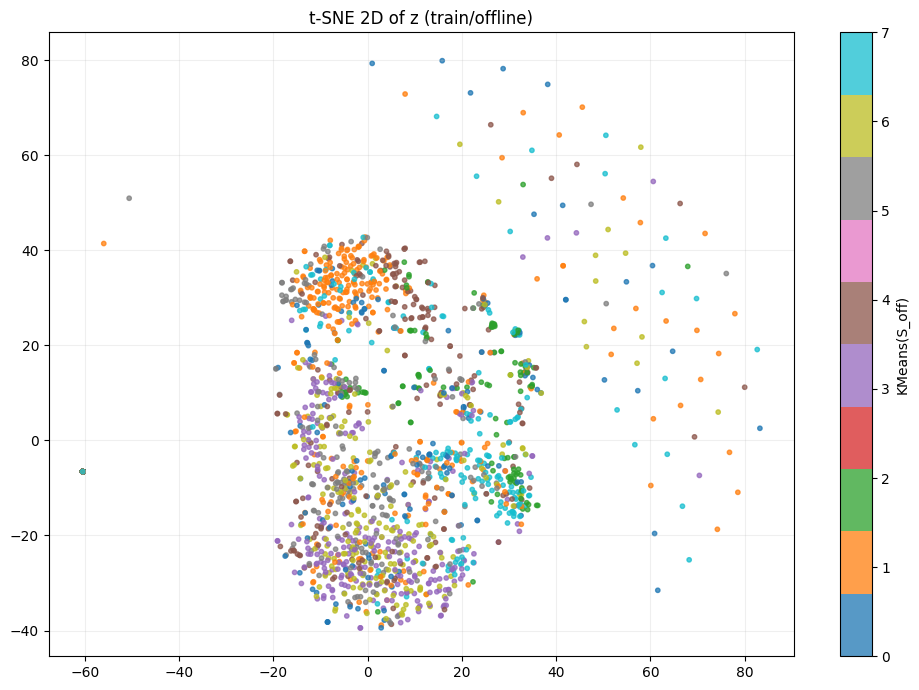

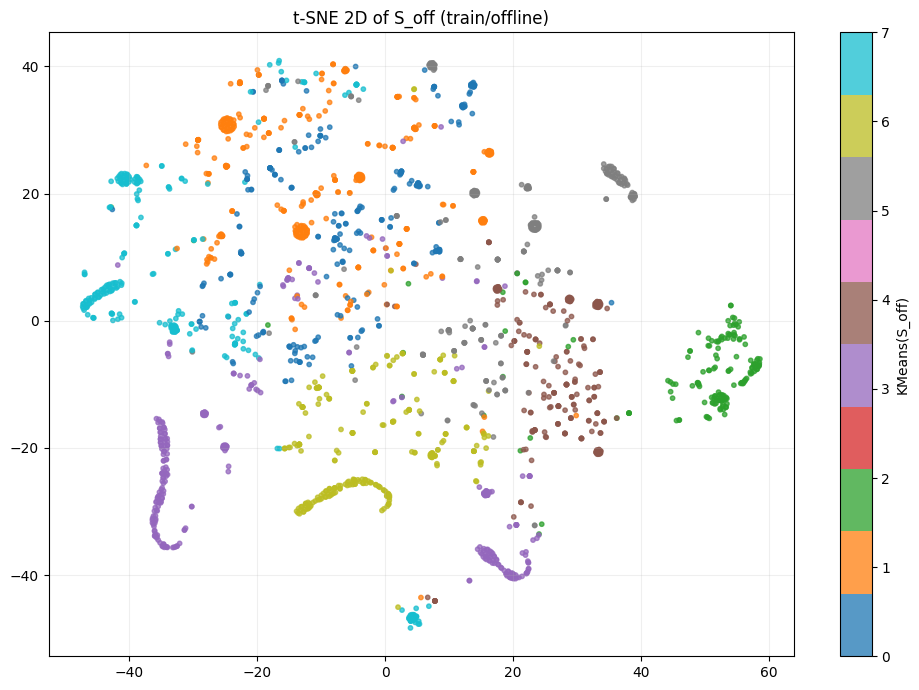

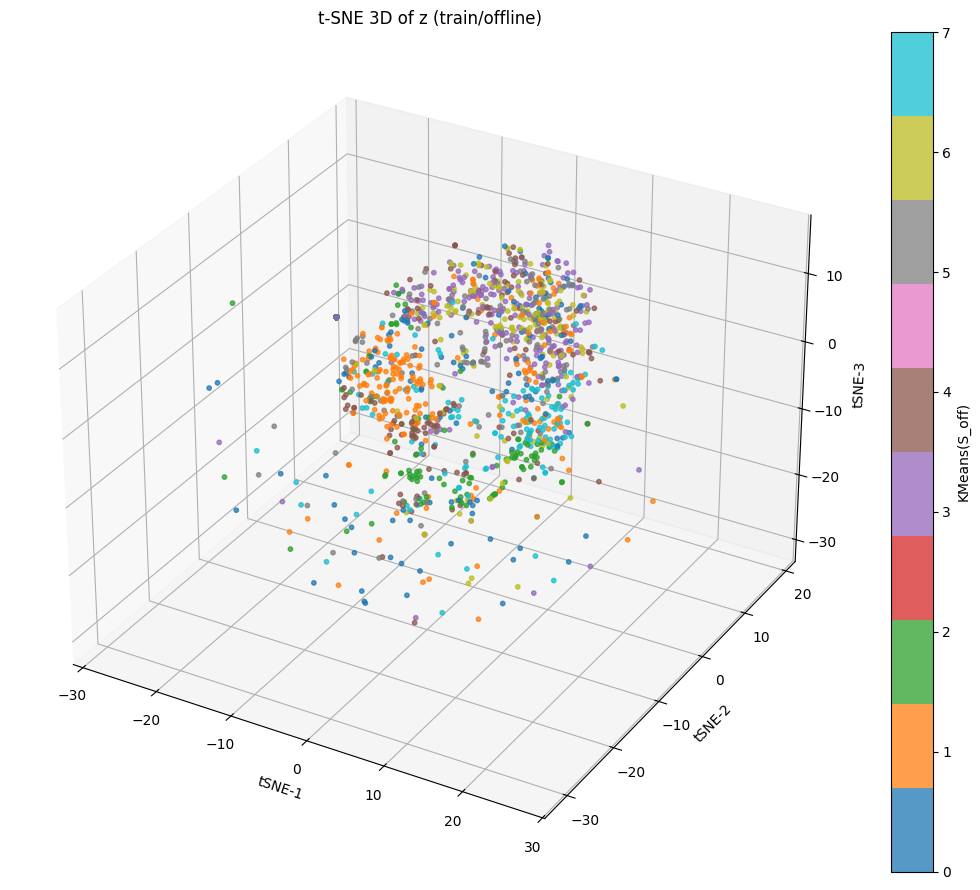

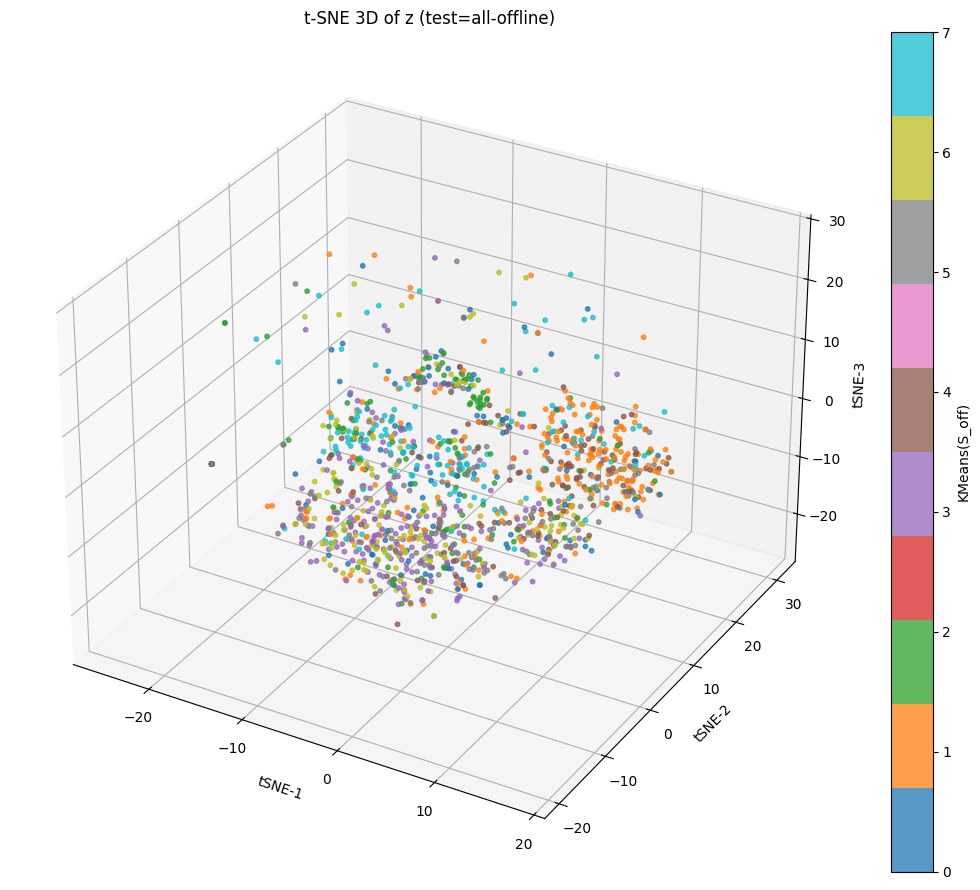

In [22]:
import random, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
torch.set_num_threads(1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/home/sjy990426/Desktop/LLM_Router/Queing_MNL_Router/Data/routerbench_dataset.csv"

use_cost = True
lambda_cost = 10.0

offline_total_ratio = 0.10
offline_seed_min_per_model = 10
offline_tie_eps = 1e-9

pos_target = 15
neg_target = 120

epochs = 200
lr = 2e-3
hidden_dim = 512
proj_dim = 128
grad_clip = 1.0
tau = 0.07

embed_model_name = "sentence-transformers/all-MiniLM-L6-v2"
embed_batch = 256

vis_n = 2000
tsne_perplexity = 30
tsne_max_iter = 1000
kmeans_k = 8

vis3_train_n = 1500
vis3_test_n = 1500
tsne3_perplexity = 30
tsne3_max_iter = 1000

def l2norm_np(x, eps=1e-12):
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + eps)

def signature(U):
    U = np.asarray(U, dtype=np.float32)
    Uc = U - U.mean(axis=1, keepdims=True)
    return l2norm_np(Uc).astype(np.float32)

def build_offline_partition_mincover_then_random(util_all, ratio, min_per, tie_eps, seed):
    U = np.asarray(util_all, dtype=np.float32)
    N, K = U.shape
    rng = np.random.RandomState(int(seed) + 999)

    n_off = int(round(float(ratio) * N))
    n_off = max(1, min(N, n_off))

    mx = U.max(axis=1, keepdims=True)
    is_top = (U >= (mx - float(tie_eps)))
    tie_size = is_top.sum(axis=1)
    strict_idx = np.where(tie_size == 1)[0].astype(np.int64)
    winners = np.argmax(U, axis=1).astype(np.int64)

    seed_list = []
    if int(min_per) > 0:
        for k in range(K):
            pool = strict_idx[winners[strict_idx] == k]
            if pool.size == 0:
                continue
            take = min(int(min_per), int(pool.size))
            seed_list.append(rng.choice(pool, size=take, replace=False).astype(np.int64))

    seed_idx = np.unique(np.concatenate(seed_list)) if seed_list else np.zeros((0,), dtype=np.int64)

    all_idx = np.arange(N, dtype=np.int64)
    remain = np.setdiff1d(all_idx, seed_idx, assume_unique=False).astype(np.int64)

    n_rand = int(n_off - seed_idx.size)
    if n_rand > 0 and remain.size > 0:
        take = min(n_rand, int(remain.size))
        rand_idx = rng.choice(remain, size=take, replace=False).astype(np.int64)
    else:
        rand_idx = np.zeros((0,), dtype=np.int64)

    offline_idx = np.concatenate([seed_idx, rand_idx]).astype(np.int64)
    offline_idx = rng.permutation(offline_idx).astype(np.int64)
    return seed_idx, rand_idx, offline_idx

class Projector(nn.Module):
    def __init__(self, d_in: int, d_hidden: int, d_out: int):
        super().__init__()
        self.B = nn.Sequential(
            nn.Linear(d_in, d_hidden),
            nn.ReLU(),
            nn.Linear(d_hidden, d_out),
            nn.LayerNorm(d_out),
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.B(x)
        return F.normalize(z, p=2, dim=1)

def trizone_mass_infonce(z, pos_mask, neg_mask, tau):
    B = int(z.size(0))
    sim = (z @ z.T) / float(tau)
    eye = torch.eye(B, device=z.device, dtype=torch.bool)
    sim = sim.masked_fill(eye, -1e9)

    ok = pos_mask.any(dim=1) & neg_mask.any(dim=1)
    if not ok.any():
        return sim.new_tensor(0.0), 0.0

    sim_ok = sim[ok]
    pos_ok = pos_mask[ok]
    neg_ok = neg_mask[ok]

    sim_pos = sim_ok.masked_fill(~pos_ok, -1e9)
    sim_den = sim_ok.masked_fill(~(pos_ok | neg_ok), -1e9)

    loss = -(torch.logsumexp(sim_pos, dim=1) - torch.logsumexp(sim_den, dim=1)).mean()
    return loss, float(ok.float().mean().item())

t0 = time.time()
df = pd.read_csv(csv_path)

meta_cols = {"sample_id", "prompt", "eval_name", "oracle_model_to_route_to"}
num_cols = [c for c in df.columns if c not in meta_cols and pd.api.types.is_numeric_dtype(df[c])]
model_cols = [c for c in num_cols if not c.endswith("|total_cost")]

perfs = df[model_cols].astype(np.float32).to_numpy()
costs = np.zeros_like(perfs, dtype=np.float32)
for j, m in enumerate(model_cols):
    cc = f"{m}|total_cost"
    if cc in df.columns:
        costs[:, j] = df[cc].astype(np.float32).to_numpy()

texts = df["prompt"].fillna("").astype(str).tolist()
N, M = perfs.shape
print(f"N={N} M={M} load_sec={time.time()-t0:.2f}")

t0 = time.time()
embedder = SentenceTransformer(embed_model_name, device=str(device))
X = embedder.encode(
    texts,
    batch_size=embed_batch,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=True
).astype(np.float32)
D = X.shape[1]
print(f"X shape={X.shape} embed_sec={time.time()-t0:.2f}")

U = perfs - float(lambda_cost) * costs if use_cost else perfs.copy()

seed_idx, rand_idx, offline_idx = build_offline_partition_mincover_then_random(
    util_all=U,
    ratio=offline_total_ratio,
    min_per=offline_seed_min_per_model,
    tie_eps=offline_tie_eps,
    seed=seed
)

all_idx = np.arange(N, dtype=np.int64)
test_idx = np.setdiff1d(all_idx, offline_idx, assume_unique=False).astype(np.int64)

X_off = X[offline_idx].astype(np.float32)
U_off = U[offline_idx].astype(np.float32)
S_off = signature(U_off)

X_te = X[test_idx].astype(np.float32)
U_te = U[test_idx].astype(np.float32)
S_te = signature(U_te)

print(f"offline={len(X_off)} test={len(X_te)} seed={len(seed_idx)} rand={len(rand_idx)}")

X_off_t = torch.from_numpy(X_off).to(device=device, dtype=torch.float32)
S_off_t = torch.from_numpy(S_off).to(device=device, dtype=torch.float32)

C = torch.clamp(S_off_t @ S_off_t.T, -1.0, 1.0)
Bsz = int(C.size(0))
eye = torch.eye(Bsz, device=device, dtype=torch.bool)

C_np = C.detach().cpu().numpy()
np.fill_diagonal(C_np, np.nan)
vals = C_np[~np.isnan(C_np)]

q_pos = 1.0 - float(pos_target) / float(Bsz - 1)
q_neg = float(neg_target) / float(Bsz - 1)
rho_pos = float(np.quantile(vals, q_pos))
rho_neg = float(np.quantile(vals, q_neg))

pos_mask = (C >= float(rho_pos)) & (~eye)
neg_mask = (C <= float(rho_neg)) & (~eye)

pos_mean = float(pos_mask.float().sum(dim=1).mean().item())
neg_mean = float(neg_mask.float().sum(dim=1).mean().item())
print(f"rho_pos={rho_pos:.6f} rho_neg={rho_neg:.6f}")
print(f"avg_pos={pos_mean:.1f} avg_neg={neg_mean:.1f} ok_ratio={(float((pos_mask.any(1)&neg_mask.any(1)).float().mean().item())):.3f}")

model = Projector(D, hidden_dim, proj_dim).to(device)
opt = torch.optim.Adam(model.parameters(), lr=float(lr))

t0 = time.time()
for ep in range(1, int(epochs) + 1):
    model.train()
    z = model(X_off_t)
    loss, ok_ratio = trizone_mass_infonce(z, pos_mask, neg_mask, tau=tau)

    opt.zero_grad(set_to_none=True)
    loss.backward()
    if grad_clip and grad_clip > 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=float(grad_clip))
    opt.step()

    if ep == 1 or ep % 20 == 0 or ep == int(epochs):
        print(f"ep={ep} loss={loss.item():.4f} ok_ratio={ok_ratio:.3f}")

print(f"train_sec={time.time()-t0:.1f}")

model.eval()
with torch.no_grad():
    z_off = model(X_off_t).detach().cpu().numpy().astype(np.float32)
    X_te_t = torch.from_numpy(X_te).to(device=device, dtype=torch.float32)
    z_te = model(X_te_t).detach().cpu().numpy().astype(np.float32)

kmeans = KMeans(n_clusters=int(kmeans_k), random_state=seed, n_init=10).fit(S_off)

rng = np.random.RandomState(seed)

n_vis = min(int(vis_n), z_off.shape[0])
idx = rng.choice(z_off.shape[0], size=n_vis, replace=False)
z_vis = z_off[idx]
s_vis = S_off[idx]
lab_vis = kmeans.predict(s_vis)

tsne_z = TSNE(n_components=2, perplexity=int(tsne_perplexity), max_iter=int(tsne_max_iter),
              init="pca", learning_rate="auto", random_state=seed)
z2 = tsne_z.fit_transform(z_vis)

plt.figure(figsize=(10,7))
sc = plt.scatter(z2[:,0], z2[:,1], c=lab_vis, s=10, alpha=0.75, cmap="tab10")
plt.colorbar(sc, label="KMeans(S_off)")
plt.title("t-SNE 2D of z (train/offline)")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

tsne_s = TSNE(n_components=2, perplexity=int(tsne_perplexity), max_iter=int(tsne_max_iter),
              init="pca", learning_rate="auto", random_state=seed)
s2 = tsne_s.fit_transform(s_vis)

plt.figure(figsize=(10,7))
sc = plt.scatter(s2[:,0], s2[:,1], c=lab_vis, s=10, alpha=0.75, cmap="tab10")
plt.colorbar(sc, label="KMeans(S_off)")
plt.title("t-SNE 2D of S_off (train/offline)")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

n3_tr = min(int(vis3_train_n), z_off.shape[0])
idx3_tr = rng.choice(z_off.shape[0], size=n3_tr, replace=False)
z3_tr_in = z_off[idx3_tr]
lab3_tr = kmeans.predict(S_off[idx3_tr])

tsne3_tr = TSNE(n_components=3, perplexity=int(tsne3_perplexity), max_iter=int(tsne3_max_iter),
                init="pca", learning_rate="auto", random_state=seed)
z3_tr = tsne3_tr.fit_transform(z3_tr_in)

fig = plt.figure(figsize=(11,9))
ax = fig.add_subplot(111, projection="3d")
p = ax.scatter(z3_tr[:,0], z3_tr[:,1], z3_tr[:,2], c=lab3_tr, s=10, alpha=0.75, cmap="tab10")
fig.colorbar(p, ax=ax, fraction=0.046, pad=0.04, label="KMeans(S_off)")
ax.set_title("t-SNE 3D of z (train/offline)")
ax.set_xlabel("tSNE-1")
ax.set_ylabel("tSNE-2")
ax.set_zlabel("tSNE-3")
plt.tight_layout()
plt.show()

n3_te = min(int(vis3_test_n), z_te.shape[0])
idx3_te = rng.choice(z_te.shape[0], size=n3_te, replace=False)
z3_te_in = z_te[idx3_te]
lab3_te = kmeans.predict(S_te[idx3_te])

tsne3_te = TSNE(n_components=3, perplexity=int(tsne3_perplexity), max_iter=int(tsne3_max_iter),
                init="pca", learning_rate="auto", random_state=seed)
z3_te = tsne3_te.fit_transform(z3_te_in)

fig = plt.figure(figsize=(11,9))
ax = fig.add_subplot(111, projection="3d")
p = ax.scatter(z3_te[:,0], z3_te[:,1], z3_te[:,2], c=lab3_te, s=10, alpha=0.75, cmap="tab10")
fig.colorbar(p, ax=ax, fraction=0.046, pad=0.04, label="KMeans(S_off)")
ax.set_title("t-SNE 3D of z (test=all-offline)")
ax.set_xlabel("tSNE-1")
ax.set_ylabel("tSNE-2")
ax.set_zlabel("tSNE-3")
plt.tight_layout()
plt.show()
